# Dataset Diagnostic — Diffusion Kernel Testing

Standalone notebook for generating and validating two new synthetic datasets.
The goal is to confirm that these datasets produce the spectral conditions
(degraded spectral gap after k-NN sparsification) that the diffusion kernel
is designed to address.

**This notebook is self-contained.** It does not depend on the main experiment
notebook. Once validated, the generators are imported into the main pipeline.

| Section | Content |
|---------|--------|
| 1 | Imports |
| 2 | `knn_affinity` utility (self-contained copy) |
| 3 | `build_symmetric_laplacian` utility |
| 4 | Generator 1 — variable-density two moons |
| 5 | Generator 2 — multi-scale clusters with bridge |
| 6 | Data visualisation |
| 7 | Eigenvalue spectrum diagnostic |
| 8 | Spectral gap comparison table |
| 9 | Assessment |

---
## Section 1 — Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# dist_mat from the project; fall back to inline cdist if import fails
try:
    from clustering.spectral import dist_mat
except ImportError:
    def dist_mat(X):
        return cdist(X, X, "euclidean")

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


---
## Section 2 — k-NN Affinity Utility

Self-contained copy of `knn_affinity`. Identical to the implementation in
`clustering/spectral.py` — included here so this notebook has no dependency
on the main experiment notebook.

In [3]:
def knn_affinity(dist_matrix, k, sigma):
    """
    Build a symmetric k-NN Gaussian affinity matrix from a precomputed
    pairwise distance matrix.

    Parameters
    ----------
    dist_matrix : (n, n) ndarray  — pairwise Euclidean distances, zero diagonal.
    k           : int             — number of nearest neighbours per point.
    sigma       : float           — Gaussian kernel bandwidth.

    Returns
    -------
    A : (n, n) ndarray  — symmetric, non-negative, zero diagonal.
    """
    n = dist_matrix.shape[0]

    # Fully connected fallback (backward-compatible)
    if k >= n - 1:
        A = np.exp(-dist_matrix ** 2 / (2.0 * sigma ** 2))
        np.fill_diagonal(A, 0.0)
        return A

    # Step 1 — k nearest neighbours per row (skip self at index 0)
    sorted_idx = np.argsort(dist_matrix, axis=1)
    nn_idx     = sorted_idx[:, 1:k + 1]          # (n, k)

    # Step 2 — directed adjacency mask
    nn_mask      = np.zeros((n, n), dtype=bool)
    rows         = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3 — OR-symmetrisation
    sym_mask = nn_mask | nn_mask.T

    # Step 4-5 — Gaussian weights applied to retained edges only
    W = np.exp(-dist_matrix ** 2 / (2.0 * sigma ** 2))
    A = W * sym_mask
    np.fill_diagonal(A, 0.0)
    return A


---
## Section 3 — Symmetric Laplacian Utility

Only the symmetric normalised Laplacian is needed for the eigenvalue
diagnostic. It is symmetric PSD, so `scipy.linalg.eigh` applies directly.

In [4]:
def build_symmetric_laplacian(A):
    """
    Compute the symmetric normalised Laplacian from affinity matrix A.

    L_s = I - D^{-1/2} A D^{-1/2}

    Parameters
    ----------
    A : (n, n) ndarray  — symmetric non-negative affinity matrix.

    Returns
    -------
    L_s : (n, n) ndarray
    d   : (n,) ndarray  — degree vector (row sums of A)
    """
    d          = A.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(d + 1e-12))
    I          = np.eye(len(A))
    L_s        = I - D_inv_sqrt @ A @ D_inv_sqrt
    return L_s, d


---
## Section 4 — Generator 1: Variable-Density Two Moons

Two half-moon arcs with controllable point counts. By setting
`n_dense >> n_sparse`, the sparse arc has far fewer samples per unit
length, making its k-NN graph locally sparser. This degrades the
spectral gap after k-NN construction — the condition the diffusion
kernel is designed to recover.

In [5]:
def generate_variable_density_moons(n_dense=500, n_sparse=50, noise=0.05, seed=42):
    """
    Two-moon dataset with unequal point densities.

    Moon 0 (label 0): dense arc with n_dense points.
    Moon 1 (label 1): sparse arc with n_sparse points.

    Parameters
    ----------
    n_dense  : int   — number of points on the dense moon.
    n_sparse : int   — number of points on the sparse moon.
    noise    : float — Gaussian noise standard deviation (added to coordinates).
    seed     : int   — random seed.

    Returns
    -------
    X : (n_dense + n_sparse, 2) ndarray
    y : (n_dense + n_sparse,)  ndarray of integer labels {0, 1}
    """
    rng = np.random.RandomState(seed)

    # Moon 0 — dense
    theta_dense = np.linspace(0, np.pi, n_dense)
    x_dense     = np.cos(theta_dense) + rng.normal(0, noise, n_dense)
    y_dense     = np.sin(theta_dense) + rng.normal(0, noise, n_dense)
    X_dense     = np.column_stack([x_dense, y_dense])
    y_label_dense = np.zeros(n_dense, dtype=int)

    # Moon 1 — sparse
    theta_sparse = np.linspace(0, np.pi, n_sparse)
    x_sparse     = 1 - np.cos(theta_sparse) + rng.normal(0, noise, n_sparse)
    y_sparse     = 0.5 - np.sin(theta_sparse) + rng.normal(0, noise, n_sparse)
    X_sparse     = np.column_stack([x_sparse, y_sparse])
    y_label_sparse = np.ones(n_sparse, dtype=int)

    # Combine and shuffle
    X    = np.vstack([X_dense, X_sparse])
    y    = np.concatenate([y_label_dense, y_label_sparse])
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


---
## Section 5 — Generator 2: Multi-Scale Clusters with Bridge

Three Gaussian clusters arranged so that Cluster 2 is diffuse and
spatially adjacent to Cluster 1. The overlap between Clusters 1 and 2
creates a 'bridge' of inter-cluster edges in the k-NN graph, which
compresses the spectral gap and makes the third eigenvector less
informative for separating those two clusters.

In [6]:
def generate_bridged_clusters(n_per_cluster=200, cov_diffuse=2.0, seed=42):
    """
    Three Gaussian clusters: two tight and one diffuse.

    Cluster 0: tight, isolated at (-4, 0).
    Cluster 1: tight, at (2, 0) — adjacent to Cluster 2.
    Cluster 2: diffuse, at (4, 0) — overlaps spatially with Cluster 1.

    The diffuse covariance of Cluster 2 (controlled by cov_diffuse) creates
    bridge edges in the k-NN graph between Clusters 1 and 2, degrading the
    spectral gap between eigenvalues 3 and 4.

    Parameters
    ----------
    n_per_cluster : int   — number of points per cluster.
    cov_diffuse   : float — variance of the diffuse cluster (Cluster 2).
    seed          : int   — random seed.

    Returns
    -------
    X : (3 * n_per_cluster, 2) ndarray
    y : (3 * n_per_cluster,)   ndarray of integer labels {0, 1, 2}
    """
    rng = np.random.RandomState(seed)

    X_0 = rng.multivariate_normal([-4.0, 0.0], 0.3 * np.eye(2), n_per_cluster)
    X_1 = rng.multivariate_normal([ 2.0, 0.0], 0.3 * np.eye(2), n_per_cluster)
    X_2 = rng.multivariate_normal([ 4.0, 0.0], cov_diffuse * np.eye(2), n_per_cluster)

    X = np.vstack([X_0, X_1, X_2])
    y = np.concatenate([
        np.zeros(n_per_cluster,  dtype=int),
        np.ones(n_per_cluster,   dtype=int),
        2 * np.ones(n_per_cluster, dtype=int),
    ])
    perm = rng.permutation(len(X))
    return X[perm], y[perm]


---
## Section 6 — Data Visualisation

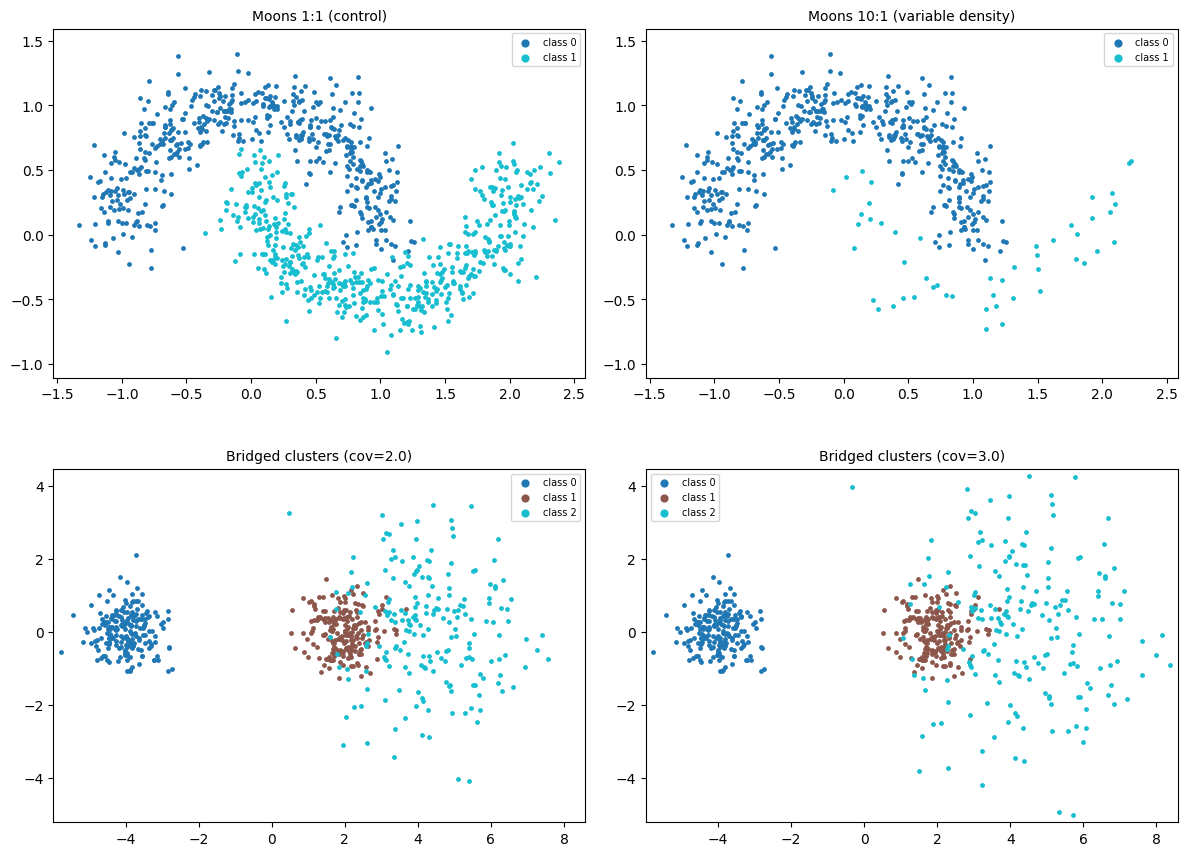

In [11]:
# Generate all four visualisation variants
X_m_1_1,  y_m_1_1  = generate_variable_density_moons(n_dense=500, n_sparse=500, noise=0.15, seed=42)
X_m_10_1, y_m_10_1 = generate_variable_density_moons(n_dense=500, n_sparse=50,  noise=0.15, seed=42)
X_b_20,   y_b_20   = generate_bridged_clusters(n_per_cluster=200, cov_diffuse=2.0, seed=42)
X_b_30,   y_b_30   = generate_bridged_clusters(n_per_cluster=200, cov_diffuse=3.0, seed=42)

panels = [
    (X_m_1_1,  y_m_1_1,  "Moons 1:1 (control)",       2),
    (X_m_10_1, y_m_10_1, "Moons 10:1 (variable density)", 2),
    (X_b_20,   y_b_20,   "Bridged clusters (cov=2.0)", 3),
    (X_b_30,   y_b_30,   "Bridged clusters (cov=3.0)", 3),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (X, y, title, nc) in zip(axes.ravel(), panels):
    cmap = plt.cm.tab10
    for i, lbl in enumerate(np.unique(y)):
        mask = y == lbl
        ax.scatter(X[mask, 0], X[mask, 1], s=6,
                   c=[cmap(i / max(nc - 1, 1))], label=f"class {lbl}")
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.legend(fontsize=7, markerscale=2)

# Consistent axis limits within each row
for row in range(2):
    ys_all = np.concatenate([panels[row*2][0][:,1], panels[row*2+1][0][:,1]])
    xs_all = np.concatenate([panels[row*2][0][:,0], panels[row*2+1][0][:,0]])
    for col in range(2):
        axes[row, col].set_xlim(xs_all.min()-0.2, xs_all.max()+0.2)
        axes[row, col].set_ylim(ys_all.min()-0.2, ys_all.max()+0.2)

plt.tight_layout()
plt.show()


---
## Section 8 — Eigenvalue Spectrum Diagnostic

For each dataset, the sigma bandwidth is set adaptively as the median
distance to the k-th nearest neighbour across all points. This avoids
hard-coding a bandwidth that may be inappropriate for the dataset's scale.

The **spectral gap** is the jump between eigenvalue q and eigenvalue q+1,
where q = true number of clusters. A large gap means the Laplacian cleanly
separates the clusters; a small gap indicates the k-NN graph has bridge
edges that blur the cluster structure.

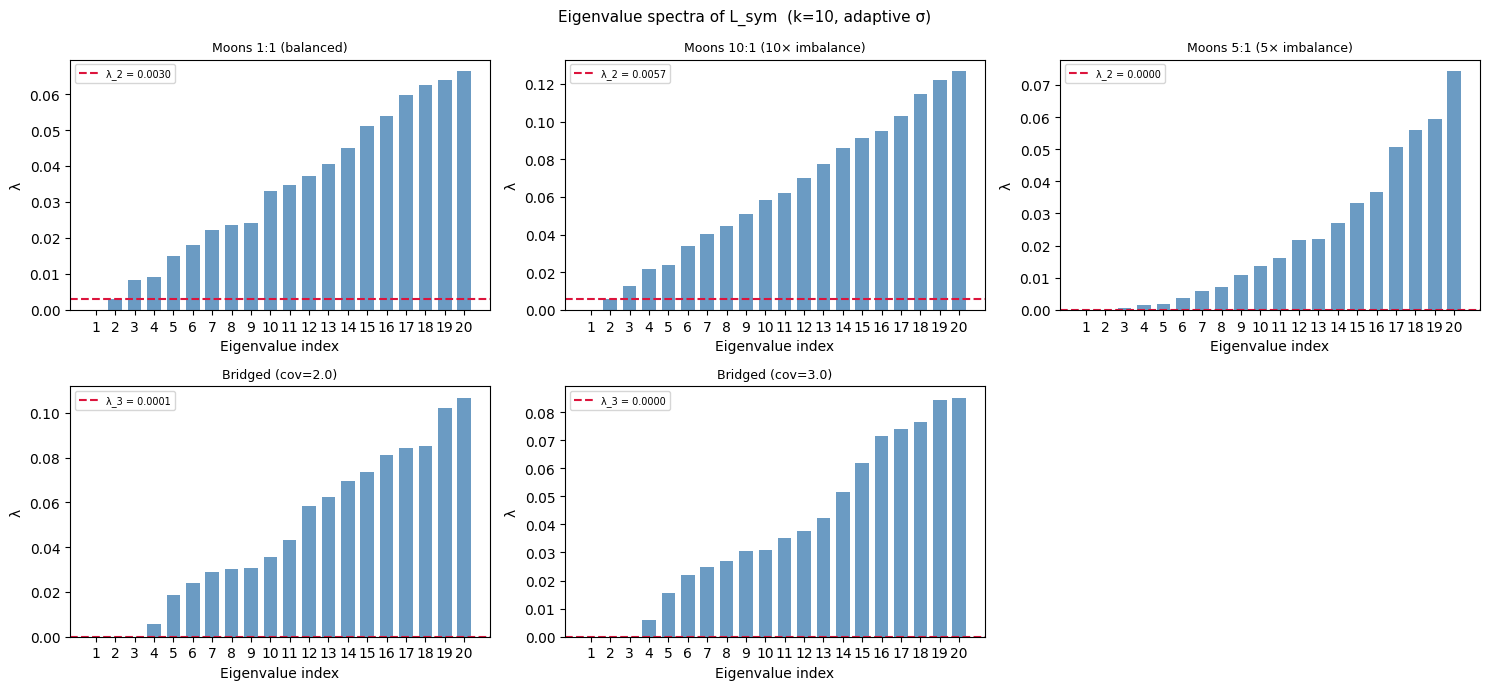

In [8]:
K_DIAG = 10  # fixed k for all diagnostics

def eigenvalue_diagnostic(X, y, k, dataset_name):
    """
    Compute eigenvalues of the symmetric Laplacian with adaptive sigma.

    Parameters
    ----------
    X            : (n, d) ndarray
    y            : (n,) integer labels (used only for n_clusters count)
    k            : int  — neighbourhood size
    dataset_name : str

    Returns
    -------
    eig_vals : (n,) ndarray  — ascending eigenvalues of L_s
    sigma    : float         — bandwidth used
    """
    D_mat       = dist_mat(X)
    sorted_d    = np.sort(D_mat, axis=1)
    sigma       = float(np.median(sorted_d[:, k]))   # median k-NN distance

    A           = knn_affinity(D_mat, k=k, sigma=sigma)
    L_s, _      = build_symmetric_laplacian(A)
    eig_vals    = scipy.linalg.eigh(L_s, eigvals_only=True)

    return eig_vals, sigma

# ── Run diagnostic on all five datasets ──────────────────────────────────────
diag_datasets = [
    (X_m_1_1,  y_m_1_1,  "Moons 1:1 (balanced)",      2),
    (X_m_10_1, y_m_10_1, "Moons 10:1 (10× imbalance)", 2),
    (generate_variable_density_moons(n_dense=500, n_sparse=100, noise=0.05, seed=42)
     + ("Moons 5:1 (5× imbalance)", 2))[:4],
    (X_b_20,   y_b_20,   "Bridged (cov=2.0)",           3),
    (X_b_30,   y_b_30,   "Bridged (cov=3.0)",           3),
]
# Fix the tuple unpacking for the 5:1 case above
X_m_5_1, y_m_5_1 = generate_variable_density_moons(n_dense=500, n_sparse=100, noise=0.05, seed=42)
diag_datasets = [
    (X_m_1_1,  y_m_1_1,  "Moons 1:1 (balanced)",       2),
    (X_m_10_1, y_m_10_1, "Moons 10:1 (10× imbalance)", 2),
    (X_m_5_1,  y_m_5_1,  "Moons 5:1 (5× imbalance)",  2),
    (X_b_20,   y_b_20,   "Bridged (cov=2.0)",           3),
    (X_b_30,   y_b_30,   "Bridged (cov=3.0)",           3),
]

diag_results = []
for X_d, y_d, name, nc in diag_datasets:
    eig_vals, sigma = eigenvalue_diagnostic(X_d, y_d, k=K_DIAG, dataset_name=name)
    diag_results.append((name, nc, eig_vals, sigma))

# ── Plot eigenvalue spectra ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.ravel()

N_SHOW = 20
for ax, (name, nc, eig_vals, sigma) in zip(axes, diag_results):
    ax.bar(np.arange(1, N_SHOW + 1), eig_vals[:N_SHOW],
           color="steelblue", alpha=0.8, width=0.7)
    # Dashed red line at the q-th eigenvalue (last cluster-relevant one)
    ax.axhline(eig_vals[nc - 1], color="crimson", linestyle="--", linewidth=1.5,
               label=f"λ_{nc} = {eig_vals[nc-1]:.4f}")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Eigenvalue index")
    ax.set_ylabel("λ")
    ax.legend(fontsize=7)
    ax.set_xticks(np.arange(1, N_SHOW + 1))

# Hide the unused sixth panel
axes[-1].set_visible(False)

plt.suptitle(f"Eigenvalue spectra of L_sym  (k={K_DIAG}, adaptive σ)", fontsize=11)
plt.tight_layout()
plt.show()


---
## Section 9 — Spectral Gap Comparison Table

In [9]:
print(f"{'Dataset':<35} | {'gap_q':>8} | {'ratio_q':>8} | {'sigma':>8}")
print("-" * 68)

for name, nc, eig_vals, sigma in diag_results:
    # Eigenvalues are 0-indexed; the q-th cluster eigenvalue is index nc-1
    # The gap is between eigenvalue nc (index nc) and eigenvalue nc-1 (index nc-1)
    lam_q      = eig_vals[nc - 1]   # last cluster-relevant eigenvalue
    lam_q1     = eig_vals[nc]       # first post-cluster eigenvalue
    gap_q      = lam_q1 - lam_q
    ratio_q    = lam_q1 / (lam_q + 1e-12)
    print(f"{name:<35} | {gap_q:>8.4f} | {ratio_q:>8.2f} | {sigma:>8.4f}")


Dataset                             |    gap_q |  ratio_q |    sigma
--------------------------------------------------------------------
Moons 1:1 (balanced)                |   0.0053 |     2.78 |   0.1637
Moons 10:1 (10× imbalance)          |   0.0069 |     2.21 |   0.1962
Moons 5:1 (5× imbalance)            |   0.0005 | 225257.68 |   0.0646
Bridged (cov=2.0)                   |   0.0057 |    70.76 |   0.3208
Bridged (cov=3.0)                   |   0.0058 |  1826.72 |   0.3379


---
## Section 10 — Assessment

*Fill in after running the diagnostic cells above.*

**Q1 — Do the variable-density moons show a degraded spectral gap?**

Compare `gap_q` and `ratio_q` for the 1:1 control against the 5:1 and 10:1 variants.
A substantially smaller gap or ratio closer to 1 confirms the dataset is suitable.

> 

**Q2 — Do the bridged clusters show a degraded spectral gap?**

Compare `gap_q` (between eigenvalue 3 and 4) against what three well-separated
blobs would produce (typically a large gap). A small gap confirms suitability.

> 

**Decision**

- If **both yes**: proceed to integrate these generators into the main diffusion
  kernel experiment notebook.
- If **either no**: adjust parameters and re-run. Suggested fixes:
  - Increase density ratio (e.g. 20:1)
  - Reduce noise (e.g. `noise=0.02`)
  - Move Cluster 2 centre closer to Cluster 1 (e.g. `(3, 0)`)
  - Increase `cov_diffuse` (e.g. 4.0 or 5.0)

**Parameters adjusted and rationale:**

> 